In [2]:
from Bio import SeqIO
from collections import Counter
from Bio.SeqUtils import gc_fraction, MeltingTemp, molecular_weight
from Bio.pairwise2 import format_alignment, align
import matplotlib.pyplot as plt
from Levenshtein import distance

seqA = SeqIO.read('dataset/a.fasta', 'fasta').seq
seqB = SeqIO.read('dataset/b.fasta', 'fasta').seq

print(seqA)
print(seqB)

GCTTTCGCCGCCTGGGAGCCGTCCGGCGCAGCAGTTTCTAGGTCCCCACTGTCCCCGCCGTCCCGCCCCTTCGCGTCCCGGGAACCGGCTGGCTTCCGAGCCGCACTCGCCGATCCTCCAGGCATGCCCCGCTACGAGCTGGCTTTAATCCTGAAAGCCATGCAGCGGCCAGAGACTGCTGCTACTTTGAAACGTACGATAGAGGCCCTGATGGACAGAGGAGCAATAGTGAGGGACTTGGAAAACCTGGGTGAACGAGCGCTTCCTTATAGGATCTCTGCCCACAGTCAGCAGCACAACAGAGGCGGGTATTTCTTGGTGGATTTTTATGCACCCACCGCAGCTGTTGAAAGCATGGTGGAGCACTTGTCTCGAGATATAGATGTGATTAGAGGGAATATTGTCAAACACCCTCTGACCCAGGAACTAAAAGAATGTGAAGGGATTGTCCCAGTCCCACTCGCAGAAAAATTATATTCCACAAAGAAGAGGAAGAAGTGAGAAGATTCGCCAGATTTTAGCCTTATATGTAATTCCTTCACATTTGGGCAGCATGGACGAGAAGGAAGAATTTGCAAGTTTGGCCTTTATATAAGCATGTGTTGCAGGTGCTGTTTGATTTTTCTAAGGTATTTTTAGCCCTTGATCCCCTTTGCTTGCGAGAGGTGGGGAACTGCTCACTGACAGCTTCTCTGTAACCTGCAGTACCAGTGGATCGTTCTTGATTTTGTTTTCATTAGTGTCATTTCTTTGTCATTGAGGACTTTTCCCCTTACAACAGTAACACCATTTTTTGAAGAGCAAAACTTATAATACCTCCTGGGATTGTGAGCTAGTCATTCAGCCTGTGTAACCATGTGGAAATAAAAATTGACGACCAATGTATTATATGGACAACTTTTGCTTTGAGTAATAAACTTGATTGTAGGAA
ATGACTCATAAAGCAACGGAGATCCTGACAGGTAAAGTTATGCAAAAATCGGTCTTAATTACCGGATG

# 1.	Sequence Manipulation 

In [3]:
# a. Find and display the length of Sequence A and B. 
len_a = len(seqA)
len_b = len(seqB)

print(len_a)
print(len_b)

931
810


In [5]:
# b.Find and display which index the first time codon (ATC) appears in both Sequence A and B. 
idxatc_seqA = seqA.index('ATC')
idxatc_seqB = seqB.index('ATC')

print(idxatc_seqA)
print(idxatc_seqB)

112
21


In [10]:
# c. Take the first 15 nucleotides from Sequence A, and the last 35 nucleotides from Sequence B. Then combine the sequences and reverse it to a new sequence, Sequence C.
cutSeqA = seqA[:15]
cutSeqB = seqB[-35:]
combine = cutSeqA + cutSeqB
seqC = combine[::-1]

print(cutSeqA)
print(cutSeqB)
print(combine)
print(seqC)

GCTTTCGCCGCCTGG
CGGGGCGCGTGATGGACAAAATATTGCAGGGGTGA
GCTTTCGCCGCCTGGCGGGGCGCGTGATGGACAAAATATTGCAGGGGTGA
AGTGGGGACGTTATAAAACAGGTAGTGCGCGGGGCGGTCCGCCGCTTTCG


# 2. Sequence Analysis & Plotting 

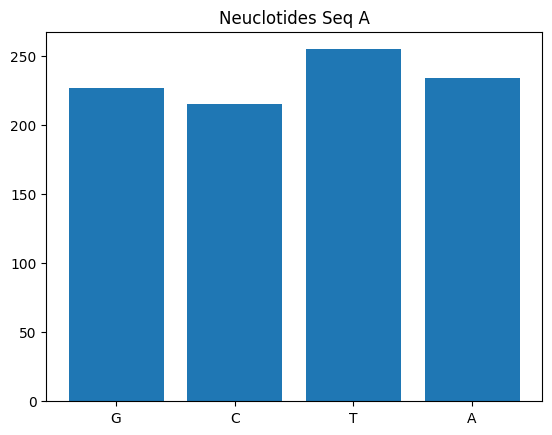

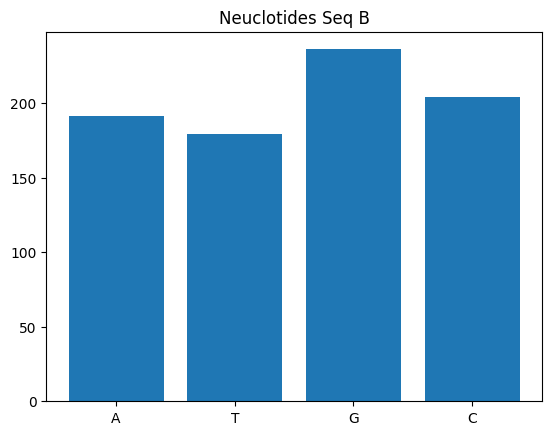

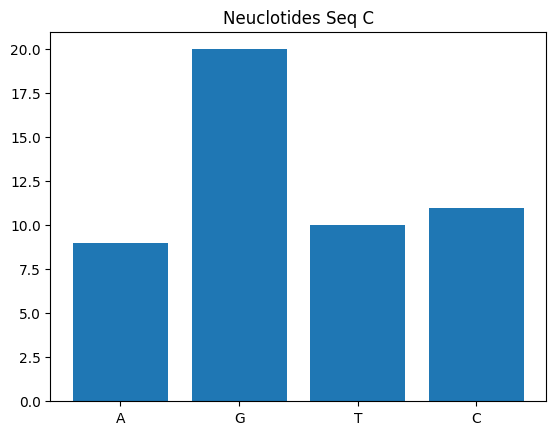

In [11]:
# a. Determine and display the nucleotides base (A, C, G, T) frequency for Sequence A, B, and C with a chart using matplotlib library. 
counter_a = Counter(seqA)
counter_b = Counter(seqB)
counter_c = Counter(seqC)

plt.bar(counter_a.keys(), counter_a.values())
plt.title("Neuclotides Seq A")
plt.show()
plt.bar(counter_b.keys(), counter_b.values())
plt.title("Neuclotides Seq B")
plt.show()
plt.bar(counter_c.keys(), counter_c.values())
plt.title("Neuclotides Seq C")
plt.show()



In [12]:
# b. Determine and display the GC & AT content percentage for Sequence A, B, and C. 

gc_seqA = gc_fraction(seqA)*100
gc_seqB = gc_fraction(seqB)*100
gc_seqC = gc_fraction(seqC)*100

print(f"GC Percentage on seqA: {gc_seqA:.2f}")
print(f"AT Percentage on seqA: {100-gc_seqA:.2f}")
print(f"GC Percentage on seqB: {gc_seqB:.2f}")
print(f"AT Percentage on seqB: {100-gc_seqB:.2f}")
print(f"GC Percentage on seqC: {gc_seqC:.2f}")
print(f"AT Percentage on seqC: {100-gc_seqC:.2f}")

GC Percentage on seqA: 47.48
AT Percentage on seqA: 52.52
GC Percentage on seqB: 54.32
AT Percentage on seqB: 45.68
GC Percentage on seqC: 62.00
AT Percentage on seqC: 38.00


In [14]:
# c. Determine and display the melting temperature for Sequence A, B, and C (using built-in Wallace, Nearest Neighbor, and GC Method). 

melt_seqA = MeltingTemp.Tm_Wallace(seqA)
melt_seqB = MeltingTemp.Tm_Wallace(seqB)
melt_seqC = MeltingTemp.Tm_Wallace(seqC)

print(melt_seqA)
print(melt_seqB)
print(melt_seqC)

2746.0
2500.0
162.0


In [15]:
# d. Determine and display the molecular weight for Sequence A, B, and C.

moleweight_seqA = molecular_weight(seqA)
moleweight_seqB = molecular_weight(seqB)
moleweight_seqC = molecular_weight(seqC)

print(moleweight_seqA)
print(moleweight_seqB)
print(moleweight_seqC)

287781.4286000008
250976.71919999958
15643.923599999998


# 3. DNA & mRNA Protein Synthesis

In [18]:
# a. Transcribe and display the DNA Sequence A, B, and C into mRNA Sequences. 
mRNA_seqA = seqA.transcribe()
mRNA_seqB = seqB.transcribe()
mRNA_seqC = seqC.transcribe()

print(mRNA_seqA)
print(mRNA_seqB)
print(mRNA_seqC)

GCUUUCGCCGCCUGGGAGCCGUCCGGCGCAGCAGUUUCUAGGUCCCCACUGUCCCCGCCGUCCCGCCCCUUCGCGUCCCGGGAACCGGCUGGCUUCCGAGCCGCACUCGCCGAUCCUCCAGGCAUGCCCCGCUACGAGCUGGCUUUAAUCCUGAAAGCCAUGCAGCGGCCAGAGACUGCUGCUACUUUGAAACGUACGAUAGAGGCCCUGAUGGACAGAGGAGCAAUAGUGAGGGACUUGGAAAACCUGGGUGAACGAGCGCUUCCUUAUAGGAUCUCUGCCCACAGUCAGCAGCACAACAGAGGCGGGUAUUUCUUGGUGGAUUUUUAUGCACCCACCGCAGCUGUUGAAAGCAUGGUGGAGCACUUGUCUCGAGAUAUAGAUGUGAUUAGAGGGAAUAUUGUCAAACACCCUCUGACCCAGGAACUAAAAGAAUGUGAAGGGAUUGUCCCAGUCCCACUCGCAGAAAAAUUAUAUUCCACAAAGAAGAGGAAGAAGUGAGAAGAUUCGCCAGAUUUUAGCCUUAUAUGUAAUUCCUUCACAUUUGGGCAGCAUGGACGAGAAGGAAGAAUUUGCAAGUUUGGCCUUUAUAUAAGCAUGUGUUGCAGGUGCUGUUUGAUUUUUCUAAGGUAUUUUUAGCCCUUGAUCCCCUUUGCUUGCGAGAGGUGGGGAACUGCUCACUGACAGCUUCUCUGUAACCUGCAGUACCAGUGGAUCGUUCUUGAUUUUGUUUUCAUUAGUGUCAUUUCUUUGUCAUUGAGGACUUUUCCCCUUACAACAGUAACACCAUUUUUUGAAGAGCAAAACUUAUAAUACCUCCUGGGAUUGUGAGCUAGUCAUUCAGCCUGUGUAACCAUGUGGAAAUAAAAAUUGACGACCAAUGUAUUAUAUGGACAACUUUUGCUUUGAGUAAUAAACUUGAUUGUAGGAA
AUGACUCAUAAAGCAACGGAGAUCCUGACAGGUAAAGUUAUGCAAAAAUCGGUCUUAAUUACCGGAUG

In [20]:
# b. Translate and display the mRNA Sequence A, B, and C into amino acids sequences.

amino_seqA = mRNA_seqA.translate()
amino_seqB = mRNA_seqB.translate()
amino_seqC = mRNA_seqC.translate()

print(amino_seqA)
print(amino_seqB)
print(amino_seqC)

AFAAWEPSGAAVSRSPLSPPSRPFASREPAGFRAALADPPGMPRYELALILKAMQRPETAATLKRTIEALMDRGAIVRDLENLGERALPYRISAHSQQHNRGGYFLVDFYAPTAAVESMVEHLSRDIDVIRGNIVKHPLTQELKECEGIVPVPLAEKLYSTKKRKK*EDSPDFSLICNSFTFGQHGREGRICKFGLYISMCCRCCLIFLRYF*PLIPFACERWGTAH*QLLCNLQYQWIVLDFVFISVISLSLRTFPLTTVTPFFEEQNL*YLLGL*ASHSACVTMWK*KLTTNVLYGQLLL*VINLIVG
MTHKATEILTGKVMQKSVLITGCSSGIGLESALELKRQGFHVLAGCRKPDDVERMNSMGFTGVLIDLDSPESVDRAADEVIALTDNCLYGIFNNAGFGMYGPLSTISRAQMEQQFSANFFGAHQLTMRLLPAMLPHGEGRIVMTSSVMGLISTPGRGAYAASKYALEAWSDALRMELRHSGIKVSLIEPGPIRTRFTDNVNQTQSDKPVENPGIAARFTLGPEAVVDKVRHAFISEKPKMRYPVTLVTWAVMVLKRLLPGRVMDKILQG*
SGDVIKQVVRGAVRRF


/opt/homebrew/Caskroom/miniforge/base/envs/ai_core/lib/python3.10/site-packages/Bio/Seq.py:2877: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(


# 4.	Sequence Alignment & Similarities

In [21]:
local_alignment_a = align.localxx(seqA, "ATCGTACGGTACCGTAA")

for alignment in local_alignment_a:
    print(format_alignment(*alignment))

843 AGCCTGTGTAACCATGTGGAAATAAAAATTGACGACCAATGTATTATATGGACAACTTTTGCTTTGAGTAATAAACTTGATTGTAGGAA
    |       |   |     |          | |||      |       |     |      |             |      ||   ||
  1 A-------T---C-----G----------T-ACG------G-------T-----A------C-------------C------GT---AA
  Score=17

839 ATTCAGCCTGTGTAACCATGTGGAAATAAAAATTGACGACCAATGTATTATATGGACAACTTTTGCTTTGAGTAATAAACTTGATTGTAGGAA
    |           |   |     |          | |||      |       |     |      |             |      ||   ||
  1 A-----------T---C-----G----------T-ACG------G-------T-----A------C-------------C------GT---AA
  Score=17

835 AGTCATTCAGCCTGTGTAACCATGTGGAAATAAAAATTGACGACCAATGTATTATATGGACAACTTTTGCTTTGAGTAATAAACTTGATTGTAGGAA
    |               |   |     |          | |||      |       |     |      |             |      ||   ||
  1 A---------------T---C-----G----------T-ACG------G-------T-----A------C-------------C------GT---AA
  Score=17

831 AGCTAGTCATTCAGCCTGTGTAACCATGTGGAAATAAAAATTGACGACCAATGTATTATATGGACAACTTTTGCTTTG

In [22]:
local_alignment_custom_a = align.localms(seqA, "ATCGTACGGTACCGTAA", 2, -1, -2, -0.5)

for alignment in local_alignment_custom_a:
    print(format_alignment(*alignment))

191 AACGTACGATAGAGGCCCTGA
    |.||||||.||    ||.|.|
  1 ATCGTACGGTA----CCGTAA
  Score=18.5



In [23]:
global_alignment_b = align.globalxx(seqB, "GGTACCGTAGCTAGGCTAATCG")

for alignment in global_alignment_b:
    print(format_alignment(*alignment))

ATGACTCATAAAGCAACGGAGATCCTGACAGGTAAAGTTATGCAAAAATCGGTCTTAATTACCGGATGTTCCAGTGGAATTGGCCTGGAAAGCGCGCTCGAATTAAAACGCCAGGGTTTTCATGTGCTGGCAGGTTGCCGGAAACCGGATGATGTTGAGCGCATGAACAGCATGGGATTTACCGGCGTGTTGATCGATCTGGATTCACCAGAAAGTGTTGATCGCGCAGCCGACGAGGTGATCGCCCTGACCGATAATTGTCTGTATGGGATCTTTAACAATGCCGGATTCGGCATGTATGGCCCCCTTTCCACCATCAGCCGTGCGCAGATGGAACAGCAGTTTTCCGCCAACTTTTTCGGCGCACACCAGCTCACCATGCGCCTGTTACCCGCGATGTTACCGCACGGTGAAGGGCGTATTGTGATGACATCATCGGTGATGGGATTAATCTCCACGCCGGGTCGTGGCGCTTACGCGGCCAGTAAATATGCGCTGGAGGCGTGGTCAGATGCACTGCGCATGGAGCTGCGCCACAGCGGAATTAAAGTCAGCCTGATCGAACCCGGTCCCATTCGTACTCGCTTCACCGACAACGTCAACCAGACGCAAAGTGATAAACCAGTCGAAAATCCCGGCATCGCCGCCCGCTTTACGTTGGGACCGGAAGCGGTGGTGGACAAAGTACGCCATGCTTTTATTAGCGAGAAGCCGAAGATGCGCTATCCGGTGACGCTGGTGACCTGGGCGGTAATGGTGCTTAAGCGCCTGCTGCCGGGGCGCGTGATGGACAAAATATTGCAGGGGTGA
                                                                                                                                                                                             

In [24]:
global_alignment_custom_b = align.globalms(seqA, "GGTACCGTAGCTAGGCTAATCG", 2, -1, -2, -0.5)

for alignment in global_alignment_custom_b:
    print(format_alignment(*alignment))

GCTTTCGCCGCCTGGGAGCCGTCCGGCGCAGCAGTTTCTAGGTCCCCACTGTCCCCGCCGTCCCGCCCCTTCGCGTCCCGGGAACCGGCTGGCTTCCGAGCCGCACTCGCCGATCCTCCAGGCATGCCCCGCTACGAGCTGGCTTTAATCCTGAAAGCCATGCAGCGGCCAGAGACTGCTGCTACTTTGAAACGTACGATAGAGGCCCTGATGGACAGAGGAGCAATAGTGAGGGACTTGGAAAACCTGGGTGAACGAGCGCTTCCTTATAGGATCTCTGCCCACAGTCAGCAGCACAACAGAGGCGGGTATTTCTTGGTGGATTTTTATGCACCCACCGCAGCTGTTGAAAGCATGGTGGAGCACTTGTCTCGAGATATAGATGTGATTAGAGGGAATATTGTCAAACACCCTCTGACCCAGGAACTAAAAGAATGTGAAGGGATTGTCCCAGTCCCACTCGCAGAAAAATTATATTCCACAAAGAAGAGGAAGAAGTGAGAAGATTCGCCAGATTTTAGCCTTATATGTAATTCCTTCACATTTGGGCAGCATGGACGAGAAGGAAGAATTTGCAAGTTTGGCCTTTATATAAGCATGTGTTGCAGGTGCTGTTTGATTTTTCTAAGGTATTTTTAGCCCTTGATCCCCTTTGCTTGCGAGAGGTGGGGAACTGCTCACTGACAGCTTCTCTGTAACCTGCAGTACCAGTGGATCGTTCTTGATTTTGTTTTCATTAGTGTCATTTCTTTGTCATTGAGGACTTTTCCCCTTACAACAGTAACACCATTTTTTGAAGAGCAAAACTTATAATACCTCCTGGGATTGTGAGCTAGTCATTCAGCCTGTGTAACCATGTGGAAATAAAAATTGACGACCAATGTATTATATGGACAACTTTTGCTTTGAGTAATAAACTTGATTGTAGGAA
|                   ||       |                           ||||       

In [25]:
distance_seqab = distance(seqA, seqB)

print(distance_seqab)

487
